###Deep Learning Lab Manual CAI2503, Prepared By IC: Pakruddin.B, Asst.Prof., PSCSE,PU. 2025-26

### Lab 3: Activation Functions & Their Effects on MLP Performance
# ---------------------------------------------------------------
Objective: Compare Sigmoid, Tanh, ReLU, and LeakyReLU activations on MNIST classification

Duration: ~2 hours (including theory, coding, and discussion)

###What Students Will Learn
How activation functions affect training speed and final accuracy.

Why Sigmoid and Tanh can suffer from vanishing gradients.

Why ReLU and LeakyReLU often train faster.

How to compare multiple models programmatically.

###Expected Outputs
Test accuracies for each activation function.

Validation accuracy plot comparing all activations.

Validation loss plot comparing all activations.

A clear observation of which activation converges faster and to higher accuracy.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



Training with activation: sigmoid
Test Accuracy with sigmoid: 0.9640

Training with activation: tanh
Test Accuracy with tanh: 0.9721

Training with activation: relu
Test Accuracy with relu: 0.9757

Training with activation: <LeakyReLU name=leaky_re_lu, built=True>
Test Accuracy with <LeakyReLU name=leaky_re_lu, built=True>: 0.9753


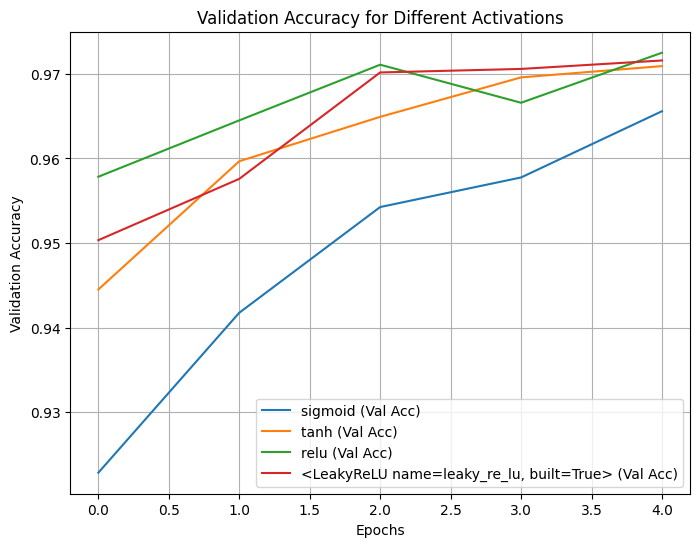

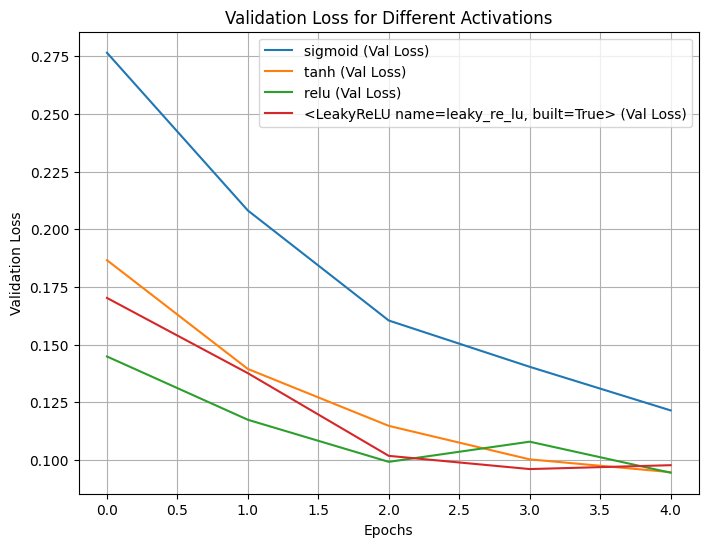


Final Test Accuracy Comparison:
sigmoid: 0.9640
tanh: 0.9721
relu: 0.9757
<LeakyReLU name=leaky_re_lu, built=True>: 0.9753


In [1]:


import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and preprocess MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten 28x28 images into vectors of size 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# 2. Function to build MLP with different activation functions
def build_mlp(activation_fn):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))
    model.add(layers.Dense(128, activation=activation_fn))
    model.add(layers.Dense(64, activation=activation_fn))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 3. Activations to compare
activations = ['sigmoid', 'tanh', 'relu', layers.LeakyReLU(alpha=0.1)]
history_results = {}
test_results = {}

# 4. Train a model for each activation
for act in activations:
    print(f"\nTraining with activation: {act}")
    model = build_mlp(act)
    history = model.fit(x_train, y_train,
                        validation_split=0.2,
                        epochs=5,  # keep epochs small for quick comparison
                        batch_size=64,
                        verbose=0)
    history_results[str(act)] = history.history
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    test_results[str(act)] = test_acc
    print(f"Test Accuracy with {act}: {test_acc:.4f}")

# 5. Plot accuracy curves for each activation
plt.figure(figsize=(8, 6))
for act, hist in history_results.items():
    plt.plot(hist['val_accuracy'], label=f'{act} (Val Acc)')
plt.title("Validation Accuracy for Different Activations")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 6. Plot training loss curves
plt.figure(figsize=(8, 6))
for act, hist in history_results.items():
    plt.plot(hist['val_loss'], label=f'{act} (Val Loss)')
plt.title("Validation Loss for Different Activations")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 7. Print final comparison table
print("\nFinal Test Accuracy Comparison:")
for act, acc in test_results.items():
    print(f"{act}: {acc:.4f}")
